In [1]:
import numpy as np
import pylab as plt
from scipy.interpolate import LinearNDInterpolator
from scipy.interpolate import griddata
from matplotlib.colors import LogNorm

from astropy import units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, Galactic, EarthLocation, AltAz
from astropy_healpix import HEALPix

import healpy as hp

# Run the BCF on several different beams

In [2]:
dB = lambda x: 10*np.log10(x)
un_dB = lambda x: 10**(x/10)

def beam_correction_factor(beam_power_db,
                           beam_alt_deg,
                           beam_az_deg,
                           beam_freqs_MHz,
                           beam_ref_idx,
                           ref_map_path="haslam408_dsds_Remazeilles2014.fits", 
                           location=None, 
                           obstime=None,
                           horizon=True):
    """
    Calculates the beam correction factor as defined in Eq. 7 of 
    Spinelli et al. (2022) [https://doi.org/10.1093/mnras/stac1804].
    
    This factor accounts for the chromaticity of the beam as it couples 
    to the radio foreground brightness temperature distribution. The 
    measured frequency spectrum (antenna pattern times sky brightness, 
    integrated over the sky at each frequency) can be divided by this 
    factor to give a partial correction for the chromatic response of 
    the beam.

    This function loads a reference temperature map, which is the Haslam 
    all-sky 408 MHz map, reprocessed by Remazeilles et al. (2015). The 
    reference frequency for the map is 408 MHz, and a simple power-law 
    spectral index of beta = -2.7 is assumed.
    
    Parameters:
        beam_power_db (array_like):
            A 2D array containing the beam power pattern in dB as a function 
            of frequency. This should not be peak-normalised. The shape 
            should be `(Nfreqs, Npixels)`.
        beam_alt_deg (array_like):
            A 1D array containing the altitude coordinate of each element of 
            `beam_power_db`, in degrees. The pattern is assumed to be 
            pointing up at zenith, i.e. the boresight points to alt=90 deg. 
        beam_az_deg (array_like):
            A 1D array containing the azimuth coordinate of each element of 
            `beam_power_db`, in degrees.
        beam_freqs_MHz (array_like):
            Frequencies that the beam correction factor should be evaluated at, 
            in MHz.
        beam_ref_idx (int):
            Which reference frequency to use from the `beam_freqs_MHz` array.
        ref_map_path (str):
            Path to the Haslam 408 MHz map, `haslam408_dsds_Remazeilles2014.fits`. This 
            can be obtained from the following URL:
            `http://www.jb.man.ac.uk/research/cosmos/haslam_map/haslam408_dsds_Remazeilles2014.fits`
        location (astropy.EarthLocation):
            Object containing the location of the observer. If left unspecified, 
            will default to Jodrell Bank, `lat=53.2421deg, lon=-2.3067deg, height=70`.
        obstime (astropy.Time):
            Object containing the time of the observation. If unspecified, will 
            default to `2025-08-01 22:00:00Z`.
        horizon (bool):
            If True, remove all contributions below the local horizon.

    Returns:
        bcf (array_like):
            Beam correction factor at each frequency. This is a dimensionless ratio.
    """
    # Load healpix reference map, assumed to be at 408 MHz
    spectral_index_ref_freq = 408. # MHz
    beta = -2.7 # spectral index for reference map power-law frequency spectrum
    ref_map = hp.fitsfunc.read_map(ref_map_path) # load map from fits file
    
    # Set up HP object, which is assuemd to be in Galactic coords
    hp_map = HEALPix(nside=hp.npix2nside(ref_map.size), order='RING', frame=Galactic())

    # Define local alt/az coordinate system
    if location is None:
        location = EarthLocation(lat=53.2421*u.deg, lon=-2.3067*u.deg, height=70.)
    if obstime is None:
        obstime = Time("2025-08-01 22:00:00Z")
    frame_altaz = AltAz(obstime=obstime, location=location)
    
    # Set up Astropy coordinate objects for each pixel of the beam
    coords = SkyCoord(beam_az_deg.ravel() * u.deg, beam_alt_deg.ravel() * u.deg, frame=frame_altaz)

    # Interpolate values of reference map onto the same coords as the beam
    tmap = hp_map.interpolate_bilinear_skycoord(coords, ref_map)

    # Apply horizon cut if needed
    if horizon:
        tmap[np.where(beam_alt_deg < 0.)] = 0.

    # Integrals of beam at ref. frequency
    # (integral of beam and sky times beam over solid angle at ref. freq.)
    # All integrals are just sums, assuming fixed pixel area (true for healpix).
    # No pixel area factor is used as they should cancel in the BCF ratio.
    beam_ref = un_dB(beam_power_db[beam_ref_idx]).flatten() # convert dB to linear gain
    tsky_ref = tmap * (beam_freqs_MHz[beam_ref_idx] / spectral_index_ref_freq)**beta
    beam_integ_ref = np.sum(beam_ref)
    sky_times_beam_integ_ref = np.sum(beam_ref * tsky_ref)
    
    # Loop over frequencies to calculate BCF
    bcf = np.zeros(beam_freqs_MHz.size)
    for i, freq in enumerate(beam_freqs_MHz):
        # Beam and sky maps at this frequency
        beam = un_dB(beam_power_db[i]).flatten()

        # Integral of beam and ref. sky times beam at this frequency
        beam_integ = np.sum(beam)
        sky_times_beam_integ = np.sum(beam * tsky_ref)

        # Populate BCF value in array
        bcf[i] = (sky_times_beam_integ / sky_times_beam_integ_ref) \
               * (beam_integ_ref / beam_integ)
    return bcf


def calculate_bcf_stats(freqs, bcf):
    """
    Very simple summary statistics about the beam correction factor.

    Parameters:
        freqs (array_like):
            Frequencies at which the BCF was evaluated. Assumed to be in MHz.
        bcf (array_like):
            Array of BCF values.

    Returns:
        stats (dict):
            Dictionary of simple summary statistics.
    """
    stats = {}
    
    # Calculate RMS value
    stats['rms'] = np.sqrt(np.mean((bcf - 1.)**2.))

    # Calculate swing
    stats['swing'] = bcf.max() - bcf.min()

    # Calculate max. absolute derivative
    stats['max_abs_deriv'] = np.max(np.abs(np.diff(bcf) / np.diff(freqs)))
    return stats

def plot_beam(data, az, za, name="Beam", is_in_dB=False, grid_only=False, normalize=False, interpolation="quadric", save_to=None):
    """
    Plot a beam. The plot is the beam projected flat onto the ground when looking from above.
    Colors indicate the beam values.
    data:
        ndarray of shape (za.size, az.size). Must not be in dB if is_in_dB is False.

    """
    grid_dim = 74
    
    assert data.shape[0] == za.size and data.shape[1] == az.size, str(data.shape)+" "+str(za.size)+" "+str(az.size)

    za_coord = np.repeat(za, az.size)
    az_coord = np.tile(az, za.size)
    data = data.ravel()


    # Cut some things where 360 goes to 0
    data = data[(az_coord<360) & (za_coord<=90)]
    _za_coord = za_coord[(az_coord<360) & (za_coord<=90)]
    az_coord = az_coord[(az_coord<360) & (za_coord<=90)]
    za_coord = _za_coord


    za_coord = np.deg2rad(za_coord)
    az_coord = np.deg2rad(az_coord)
    r = np.sin(za_coord)
    x = r*np.sin(az_coord)
    y = r*np.cos(az_coord)  

    X = np.linspace(-1, 1, num=grid_dim)
    Y = np.linspace(-1, 1, num=grid_dim)

    X, Y = np.meshgrid(X, Y)  # 2D grid for interpolation
    interp = LinearNDInterpolator(list(zip(x, y)), data)

    grid = interp(X, Y).T   

    if normalize: grid /= np.nanmax(grid)

    if grid_only: return grid

    plt.clf()

    if not is_in_dB:
        grid = dB(grid)
    im=plt.imshow(grid, interpolation=interpolation, cmap="rainbow")
    plt.xticks([])
    plt.yticks([])


    if False:
        points = np.arange(0, 2*np.pi, 0.01)
        for deg in [ 30, 45, 60, 75 ]:
            r = np.cos(deg*np.pi/180)
            x = r*np.cos(points)
            y = r*np.sin(points)
            plt.text(r/np.sqrt(2), -r/np.sqrt(2), "    $"+str(deg)+"^\\circ$", c="w")
            plt.scatter(x, y, s=0.01, c='w', marker='o')
    

    cbar = plt.colorbar(im,fraction=0.04, pad=0.04)
    cbar.set_label("Beam power [dB]")
    plt.title(name, fontsize=10)

    for pos in ['right', 'top', 'bottom', 'left']: 
        plt.gca().spines[pos].set_visible(False) 
    # shape.custom3d()
    #show()
    # or just show(h2) replace with image dump

    if save_to is not None:
        plt.savefig(save_to)

def load_uan(fname):
    """
    Load antenna pattern data from a UAN text file.
    """
    def strip_header(f):
        # Parse and strip header lines from input file
        phi_inc = theta_inc = magnitude = None    # need these to process the file
        line = f.readline()
        while "end_<parameters>" not in line:
            if "phi_inc" in line:
                phi_inc = int(line.split()[1])
            if "theta_inc" in line:
                theta_inc = int(line.split()[1])
            if "magnitude" in line:
                magnitude_unit = line.split()[1]
            if "frequencyHz" in line:
                freq_hz = float(line.split()[1])
            line = f.readline()

        # Check headers were found
        assert  phi_inc is not None \
            and theta_inc is not None \
            and magnitude_unit is not None \
            and freq_hz is not None, \
            "Required headers missing"
        return phi_inc, theta_inc, magnitude_unit, freq_hz

    # Helper conversion functions
    no_change = lambda vals: vals
    
    # Open file and parse data
    with open(fname) as f:
        # Parse header
        za_inc, az_inc, magnitude_type, freq_hz = strip_header(f)

        # Load data from remaining rows in file
        uan_values = np.loadtxt(f)

    # Zenith angle and azimuth arrays
    za = np.sort(np.unique(uan_values[:, 0])).astype(int)
    az = np.sort(np.unique(uan_values[:, 1])).astype(int)

    # Rescaling function
    scale = no_change
    if magnitude_type == "dB":
        scale = un_dB

    # Unpack antenna pattern values
    # (Naxes_vec, 1, Nfeeds or Npols, Nfreqs, Naxes2, Naxes1)
    values = np.zeros((za.size, az.size))      
    for i in range(uan_values.shape[0]):
        _za = int(uan_values[i, 0])
        _az = int(uan_values[i, 1])
        
        assert values[_za//za_inc, _az//az_inc] == 0, \
               f"az={_az}, za={_za} already has a value"

        # Convert gains to power. See https://github.com/hughbg/GENETIS_RHINO/blob/master/UAN_process_beam.pdf
        G_linear_za = scale(uan_values[i, 2])
        G_linear_az = scale(uan_values[i, 3])
        values[_za//za_inc, _az//az_inc] = G_linear_za+G_linear_az


    # Check that array is filled
    assert np.min(values) != 0
    return freq_hz, za, az, values

def do_bcf_run(beam_power_db, az, za, beam_freqs):
    """
    beam_power_db:
        ndarray of shape (freq.size, za.size, az.size). In db
    az:
        1-D ndarray of azimuth angles in degrees which should go from 0 to 359/360 degrees
    za:
        1-D ndarray of zenith angles in degrees which should go from 0 to 179/180 degrees
    freq:
        Frequencies in Hz
    
    """

    assert beam_power_db[0].shape[0] == za.size and beam_power_db[0].shape[1] == az.size, str(data.shape)+" ("+str(za.size)+", "+str(az.size)+")"

    alt = 90-za
    az_grid, alt_grid = np.meshgrid(az, alt)

    # Calculate beam correction factor
    beam_freqs = np.linspace(50., 100., 50) # MHz
    bcf = beam_correction_factor(beam_power_db=beam_power_db,
                                 beam_alt_deg=alt_grid.flatten(),
                                 beam_az_deg=az_grid.flatten(),
                                 beam_freqs_MHz=beam_freqs,
                                 beam_ref_idx=beam_freqs.size//2,
                         )
    
    print("\nBCF stats:", calculate_bcf_stats(beam_freqs, bcf))
    
    # Plot the beam and BCF. All beams are the same 
    gridded = plot_beam(beam_power_db[10], az, za, is_in_dB=True, grid_only=True)
    
    plt.figure(figsize=(12, 4))
    plt.subplot(121)
    im=plt.imshow(gridded, interpolation="quadric", cmap="rainbow")
    plt.xticks([])
    plt.yticks([])    
    cbar = plt.colorbar(im,fraction=0.04, pad=0.04)
    cbar.set_label("Beam power [dB]")
    plt.title("Beam[10]", fontsize=10)
    for pos in ['right', 'top', 'bottom', 'left']: 
        plt.gca().spines[pos].set_visible(False) 
    
    plt.subplot(122)
    plt.plot(beam_freqs, bcf)
    plt.xlabel("Freq. [MHz]")
    #plt.ylabel("BCF")
    plt.title("BCF")
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)



## Fake beam

Gaussian-like but with a ripple over frequency.


BCF stats: {'rms': np.float64(0.0002998732435338313), 'swing': np.float64(0.0005732015097337229), 'max_abs_deriv': np.float64(7.82228664564231e-05)}


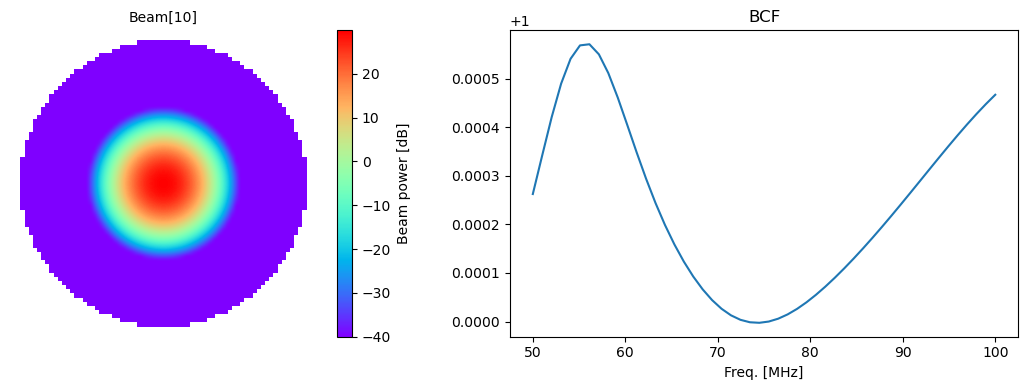

In [3]:
# Generate fictitious beam pattern and coords
az = np.linspace(0., 360., 360) 
za = np.linspace(0, 180, 180)
alt = 90-za
az_grid, alt_grid = np.meshgrid(az, alt)

# Make fictitious beam pattern as fn. of frequency
width_alt = 5. # deg
beam_freqs = np.linspace(50., 100., 50) # MHz
beam_width = width_alt * (1. + 0.1 * np.cos(14 * beam_freqs[0]/beam_freqs)) # artificial ripple
 
beam_power_db = np.array([np.exp(-0.5 * ((90-alt_grid) / beam_width[i])**2.)*1000 for i in range(len(beam_freqs))])
beam_power_db[beam_power_db<0.0001] = 0.0001
beam_power_db = dB(beam_power_db)

do_bcf_run(beam_power_db, az, za, beam_freqs)

## UAN Beam

UAN Beams are used in the GENETIS project. I only have a beam at one frequency so I'll replicate it for all frequencies which means the bcf should be flat. Test case, plus UAN usage example.


BCF stats: {'rms': np.float64(0.0), 'swing': np.float64(0.0), 'max_abs_deriv': np.float64(0.0)}


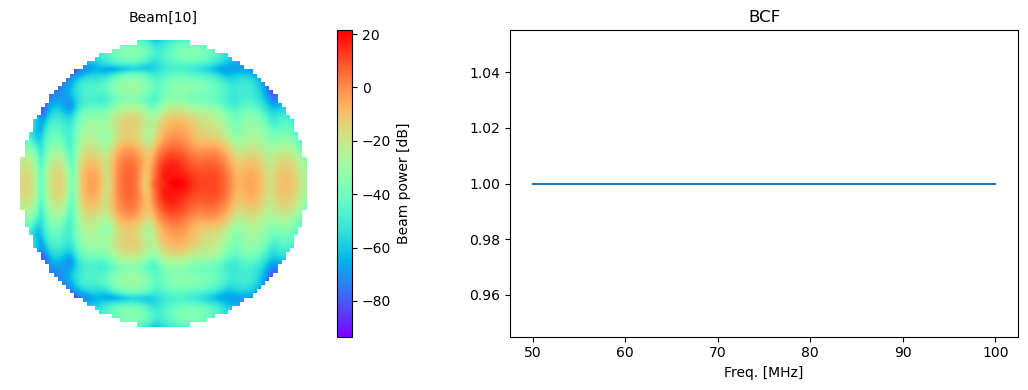

In [4]:
uan_file = "23_9_1.uan"

freq_hz, za, az, uan_beam = load_uan(uan_file)

# Replicate beam over frequencies
freqs = np.linspace(50., 100., 50)
beam_power_db = np.zeros((freqs.size, uan_beam.shape[0], uan_beam.shape[1]))
beam_power_db[:] = dB(uan_beam)

do_bcf_run(beam_power_db, az, za, beam_freqs)

## Beams in HornDry

Beams from https://drive.google.com/drive/folders/1n1lTqd1QhXBwG20lvsKaxX46FZVCIfcB. The zip files have beams that vary by frequency. They are in healpix format. 

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 

BCF stats: {'rms': np.float64(0.027428411497996866), 'swing': np.float64(0.07267317612596336), 'max_abs_deriv': np.float64(0.00488689349365824)}


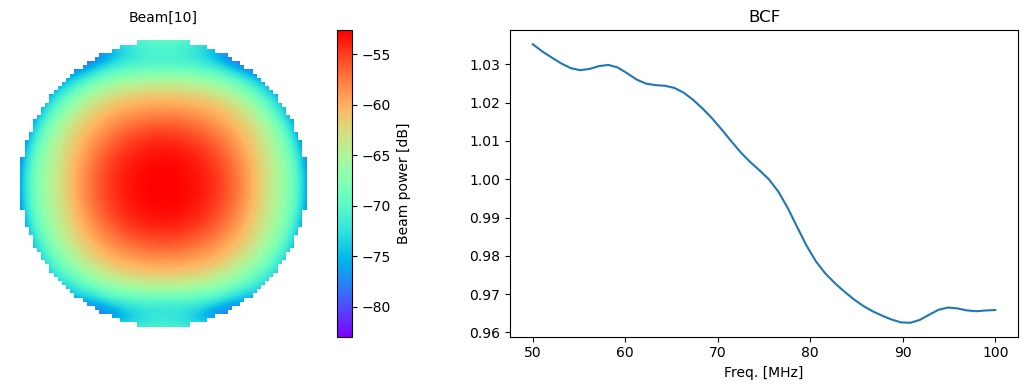

In [5]:
# Get the za/az from healpix

nside = 512                          # Just happen to know this for these files
npix = hp.nside2npix(nside)
pixels = np.arange(npix)

theta, phi = hp.pix2ang(nside, pixels)


# We have to interpolate the beams onto a grid, so setup the grid properties
points = np.array((np.rad2deg(theta), np.rad2deg(phi))).T
az = np.arange(361) 
za = np.arange(181) 
az_grid, za_grid = np.meshgrid(az, za)


# Get the beams, put on grid, and change to db
freqs = np.linspace(55, 85, 61)      # Range of the files
beam_power_db = np.zeros((freqs.size, za.size, az.size))

for i, f in enumerate(freqs):
    print(i, end=" ")
    fname = f"HornDry/HornDry{f:.1f}.fits"
    beam = hp.fitsfunc.read_map(fname)
    beam_power_db[i] = griddata(points, beam, (za_grid, az_grid), method="nearest")
print()

beam_power_db = dB(beam_power_db)

do_bcf_run(beam_power_db, az, za, freqs)

## Beams in rhino-beams

https://github.com/RHINO-Experiment/rhino-beams/tree/main. 

The beams vary by frequency. There is a beamfits and an npy version, the npy is easier to work with but we can get some info from the beamfits.

1 5

BCF stats: {'rms': np.float64(0.02890222904736174), 'swing': np.float64(0.08556584953454305), 'max_abs_deriv': np.float64(0.003311816197244583)}


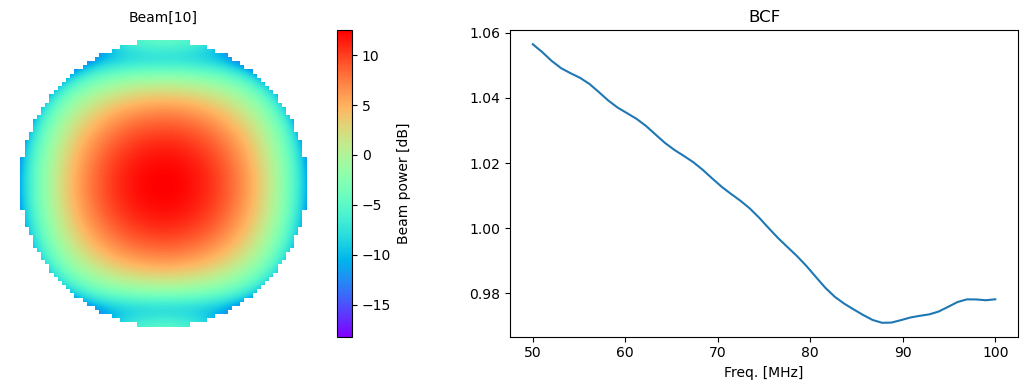

In [6]:

# Get params from beamfits
from pyuvdata import UVBeam

uvb = UVBeam()
uvb.read_beamfits("rhino_08_2024b.beamfits")
za = np.rad2deg(uvb.axis2_array)
az = np.rad2deg(uvb.axis1_array)

# Get data
beam_power_db = np.load("rhino_beam_per_freq.npy")

do_bcf_run(beam_power_db, az, za, uvb.freq_array)